In [1]:
import pandas as pd

from fetch_datasets import fetch_datasets
from preprocess_datasets import preprocess
from data_splitting import data_splitting
from model import solar_predictor_model
from train import train_my_model
from test import test_model
from evaluate import evaluate_model

from dataset import SolarDataset
from torch.utils.data import DataLoader


import matplotlib.pyplot as plt



#first step is to fetch the datasets and save them
fetch_datasets()

data_chester = pd.read_csv(f'./data_chester.csv')
data_chester.head(10)


/Users/benji/Documents/dissertation/python_environment/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


CSV created successfully with shape: (26280, 12)
CSV created successfully with shape: (26280, 12)


,YEAR,MO,DY,HR,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,CLOUD_AMT,SZA,PS,RH2M,T2M,WS2M
0,2023,1,1,0,0.00,0.0,93.86,90.00,97.85,92.33,7.55,4.86
1,2023,1,1,1,0.00,0.0,82.74,90.00,97.93,92.66,7.27,4.76
2,2023,1,1,2,0.00,0.0,33.93,90.00,98.00,93.06,6.95,4.56
3,2023,1,1,3,0.00,0.0,72.31,90.00,98.06,93.46,6.70,4.37
4,2023,1,1,4,0.00,0.0,78.93,90.00,98.11,93.47,6.63,4.29
5,2023,1,1,5,0.00,0.0,98.21,90.00,98.16,92.84,6.61,4.27
6,2023,1,1,6,0.00,0.0,99.19,90.00,98.20,92.57,6.38,4.14
7,2023,1,1,7,0.00,0.0,99.52,90.00,98.26,92.79,6.15,4.08
8,2023,1,1,8,0.00,0.0,99.43,90.00,98.33,93.58,6.14,3.98
9,2023,1,1,9,67.72,41.3,86.21,84.22,98.38,92.73,6.81,4.09


In [2]:
data_lagos = pd.read_csv(f'./data_lagos.csv')
data_lagos.head(10)

,YEAR,MO,DY,HR,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,CLOUD_AMT,SZA,PS,RH2M,T2M,WS2M
0,2023,1,1,0,0.00,0.00,30.11,90.00,100.79,57.78,24.10,0.82
1,2023,1,1,1,0.00,0.00,21.31,90.00,100.74,64.77,22.65,1.12
2,2023,1,1,2,0.00,0.00,7.99,90.00,100.72,71.22,21.58,1.48
3,2023,1,1,3,0.00,0.00,4.72,90.00,100.73,75.40,20.99,1.89
4,2023,1,1,4,0.00,0.00,3.54,90.00,100.76,79.18,20.38,1.99
5,2023,1,1,5,0.00,0.00,5.62,90.00,100.81,82.06,19.77,2.00
6,2023,1,1,6,59.30,58.58,4.66,83.30,100.87,82.49,19.79,2.07
7,2023,1,1,7,273.27,270.27,3.72,69.91,100.94,77.50,20.62,2.28
8,2023,1,1,8,494.00,491.15,2.77,57.06,100.98,73.86,21.94,1.84
9,2023,1,1,9,687.35,685.47,1.83,45.24,100.95,68.19,24.05,1.59


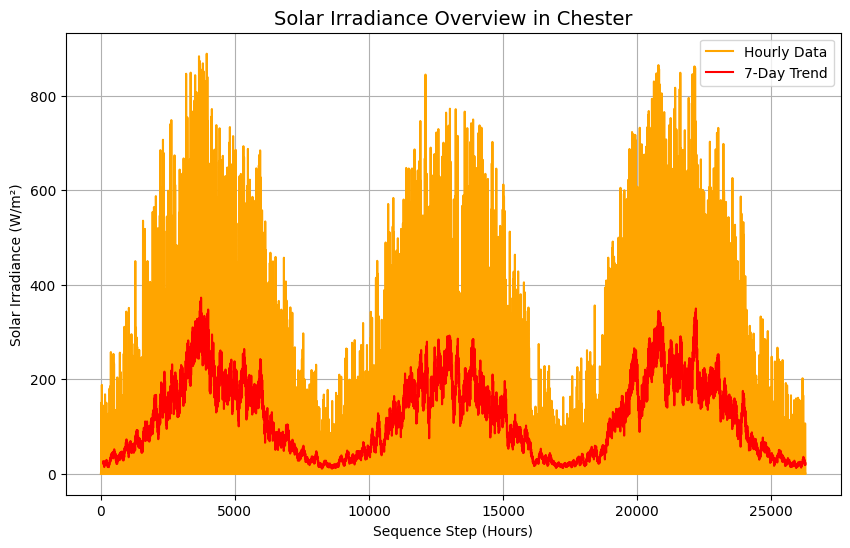

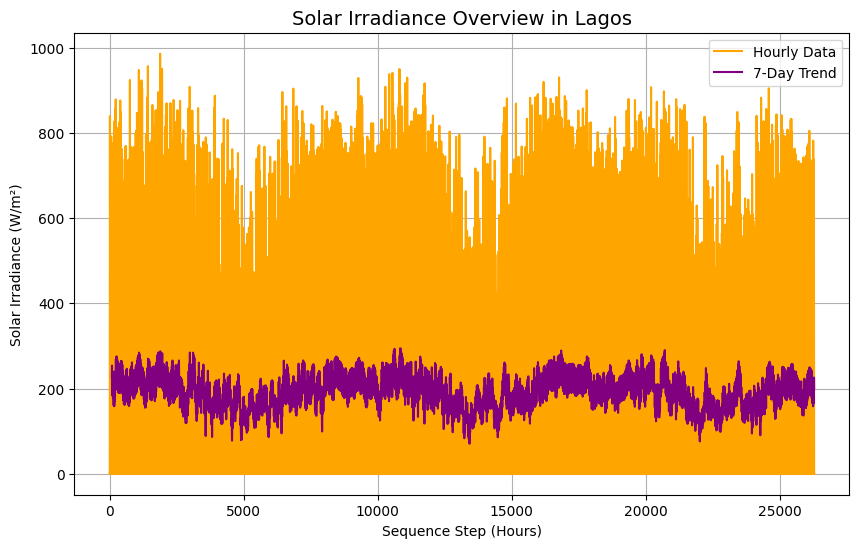

In [3]:
target_col = 'ALLSKY_SFC_SW_DWN' # This is the column we want to visualize

plt.figure(figsize=(10, 6))
plt.plot(data_chester[target_col], color='orange', label='Hourly Data')
# # Adding a rolling mean to see the seasonal trend (e.g., 7-day window)
# If your day is ~12 steps after cleaning, 7 days = 84 steps
plt.plot(data_chester[target_col].rolling(window=84).mean(), color='red', label='7-Day Trend')
plt.title('Solar Irradiance Overview in Chester', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.figure(figsize=(10, 6))
plt.plot(data_lagos[target_col], color='orange', label='Hourly Data')
# # Adding a rolling mean to see the seasonal trend (e.g., 7-day window)
# If your day is ~12 steps after cleaning, 7 days = 84 steps
plt.plot(data_lagos[target_col].rolling(window=84).mean(), color='purple', label='7-Day Trend')
plt.title('Solar Irradiance Overview in Lagos', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.show()

In [4]:

#second step is to preprocess the datasets and save them
preprocess(data_chester, data_lagos)

preprocessed_data_chester = pd.read_csv(f'./preprocessed_chester.csv')
preprocessed_data_lagos = pd.read_csv(f'./preprocessed_lagos.csv')


In [5]:
preprocessed_data_chester.head(10)

,YEAR,MO,DY,HR,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,CLOUD_AMT,SZA,PS,RH2M,T2M,WS2M,Hour_sine,Hour_cosine,DayOfYear,DayOfYear_sine,DayOfYear_cosine
0,2023,1,1,0,0.000000,0.000000,0.9386,1.000000,0.417569,0.865792,0.378298,0.437331,0.000000,1.000000e+00,1,0.017202,0.999852
1,2023,1,1,1,0.000000,0.000000,0.8274,1.000000,0.427196,0.871566,0.369063,0.428314,0.258819,9.659258e-01,1,0.017202,0.999852
2,2023,1,1,2,0.000000,0.000000,0.3393,1.000000,0.435620,0.878565,0.358509,0.410280,0.500000,8.660254e-01,1,0.017202,0.999852
3,2023,1,1,3,0.000000,0.000000,0.7231,1.000000,0.442840,0.885564,0.350264,0.393147,0.707107,7.071068e-01,1,0.017202,0.999852
4,2023,1,1,4,0.000000,0.000000,0.7893,1.000000,0.448857,0.885739,0.347955,0.385933,0.866025,5.000000e-01,1,0.017202,0.999852
5,2023,1,1,5,0.000000,0.000000,0.9821,1.000000,0.454874,0.874716,0.347296,0.384130,0.965926,2.588190e-01,1,0.017202,0.999852
6,2023,1,1,6,0.000000,0.000000,0.9919,1.000000,0.459687,0.869991,0.339710,0.372408,1.000000,6.123234e-17,1,0.017202,0.999852
7,2023,1,1,7,0.000000,0.000000,0.9952,1.000000,0.466907,0.873841,0.332124,0.366997,0.965926,-2.588190e-01,1,0.017202,0.999852
8,2023,1,1,8,0.000000,0.000000,0.9943,1.000000,0.475331,0.887664,0.331794,0.357980,0.866025,-5.000000e-01,1,0.017202,0.999852
9,2023,1,1,9,0.075316,0.046468,0.8621,0.903085,0.481348,0.872791,0.353892,0.367899,0.707107,-7.071068e-01,1,0.017202,0.999852


In [6]:
preprocessed_data_lagos.head(10)

,YEAR,MO,DY,HR,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,CLOUD_AMT,SZA,PS,RH2M,T2M,WS2M,Hour_sine,Hour_cosine,DayOfYear,DayOfYear_sine,DayOfYear_cosine
0,2023,1,1,0,0.000000,0.000000,0.3011,1.000000,0.441176,0.301109,0.394065,0.132328,0.000000,1.000000e+00,1,0.017202,0.999852
1,2023,1,1,1,0.000000,0.000000,0.2131,1.000000,0.404412,0.416818,0.293996,0.182580,0.258819,9.659258e-01,1,0.017202,0.999852
2,2023,1,1,2,0.000000,0.000000,0.0799,1.000000,0.389706,0.523589,0.220152,0.242881,0.500000,8.660254e-01,1,0.017202,0.999852
3,2023,1,1,3,0.000000,0.000000,0.0472,1.000000,0.397059,0.592783,0.179434,0.311558,0.707107,7.071068e-01,1,0.017202,0.999852
4,2023,1,1,4,0.000000,0.000000,0.0354,1.000000,0.419118,0.655355,0.137336,0.328308,0.866025,5.000000e-01,1,0.017202,0.999852
5,2023,1,1,5,0.000000,0.000000,0.0562,1.000000,0.455882,0.703029,0.095238,0.329983,0.965926,2.588190e-01,1,0.017202,0.999852
6,2023,1,1,6,0.059760,0.059394,0.0466,0.920654,0.500000,0.710147,0.096618,0.341709,1.000000,6.123234e-17,1,0.017202,0.999852
7,2023,1,1,7,0.275391,0.274024,0.0372,0.762080,0.551471,0.627545,0.153899,0.376884,0.965926,-2.588190e-01,1,0.017202,0.999852
8,2023,1,1,8,0.497833,0.497972,0.0277,0.609901,0.580882,0.567290,0.244997,0.303183,0.866025,-5.000000e-01,1,0.017202,0.999852
9,2023,1,1,9,0.692684,0.694991,0.0183,0.469919,0.558824,0.473432,0.390614,0.261307,0.707107,-7.071068e-01,1,0.017202,0.999852


Target column starts at index: 26256


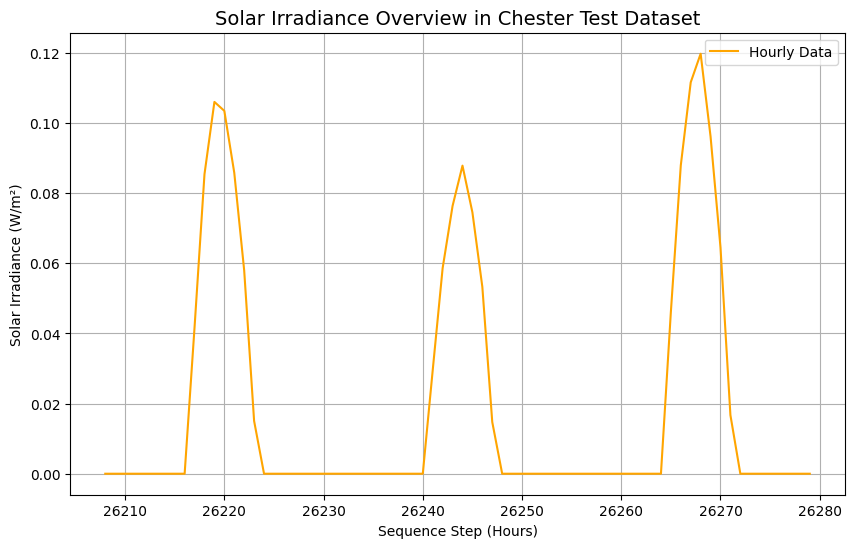

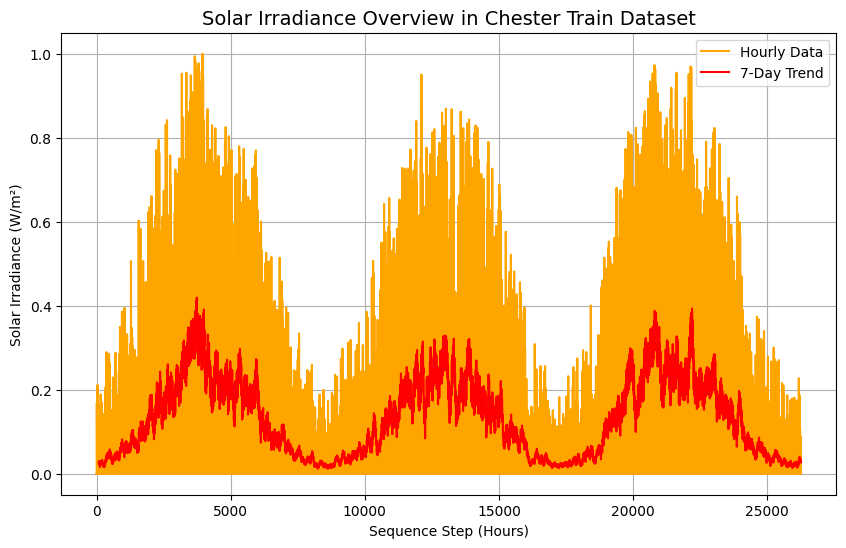

,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,CLOUD_AMT,SZA,T2M,RH2M,PS,WS2M,Hour_sine,Hour_cosine,DayOfYear_sine,DayOfYear_cosine
0,0.000000,0.000000,0.9386,1.000000,0.378298,0.865792,0.417569,0.437331,0.000000,1.000000e+00,0.017202,0.999852
1,0.000000,0.000000,0.8274,1.000000,0.369063,0.871566,0.427196,0.428314,0.258819,9.659258e-01,0.017202,0.999852
2,0.000000,0.000000,0.3393,1.000000,0.358509,0.878565,0.435620,0.410280,0.500000,8.660254e-01,0.017202,0.999852
3,0.000000,0.000000,0.7231,1.000000,0.350264,0.885564,0.442840,0.393147,0.707107,7.071068e-01,0.017202,0.999852
4,0.000000,0.000000,0.7893,1.000000,0.347955,0.885739,0.448857,0.385933,0.866025,5.000000e-01,0.017202,0.999852
5,0.000000,0.000000,0.9821,1.000000,0.347296,0.874716,0.454874,0.384130,0.965926,2.588190e-01,0.017202,0.999852
6,0.000000,0.000000,0.9919,1.000000,0.339710,0.869991,0.459687,0.372408,1.000000,6.123234e-17,0.017202,0.999852
7,0.000000,0.000000,0.9952,1.000000,0.332124,0.873841,0.466907,0.366997,0.965926,-2.588190e-01,0.017202,0.999852
8,0.000000,0.000000,0.9943,1.000000,0.331794,0.887664,0.475331,0.357980,0.866025,-5.000000e-01,0.017202,0.999852
9,0.046468,0.075316,0.8621,0.903085,0.353892,0.872791,0.481348,0.367899,0.707107,-7.071068e-01,0.017202,0.999852


In [7]:
# Split the preprocessed data into training and testing sets

chester_train, chester_test, lagos_train, lagos_test, id = data_splitting(preprocessed_data_chester, preprocessed_data_lagos)
print(f"Target column starts at index: {id}")
plt.figure(figsize=(10, 6))
plt.plot(chester_test[target_col], color='orange', label='Hourly Data')
plt.title('Solar Irradiance Overview in Chester Test Dataset', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.figure(figsize=(10, 6))
plt.plot(chester_train[target_col], color='orange', label='Hourly Data')
# # Adding a rolling mean to see the seasonal trend (e.g., 7-day window)
# If your day is ~12 steps after cleaning, 7 days = 84 steps
plt.plot(chester_train[target_col].rolling(window=84).mean(), color='red', label='7-Day Trend')
plt.title('Solar Irradiance Overview in Chester Train Dataset', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.show()
chester_train.head(10)

Target column starts at index: 26256


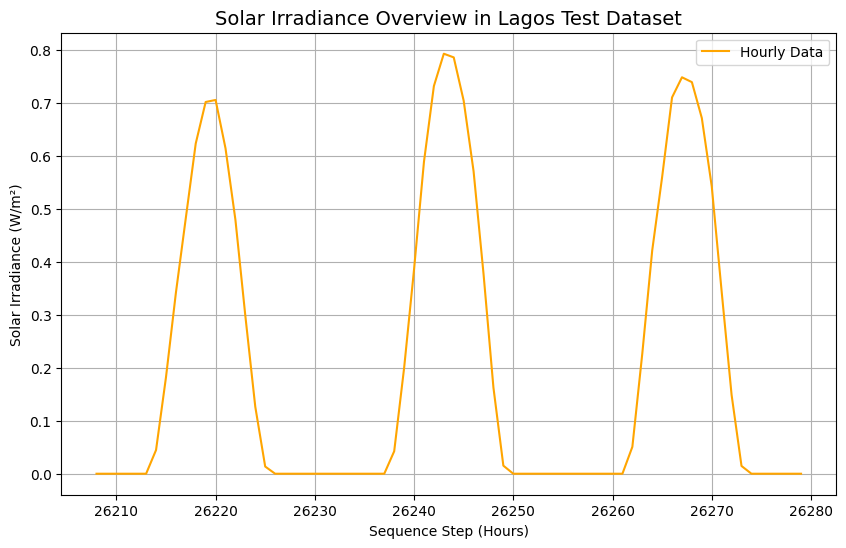

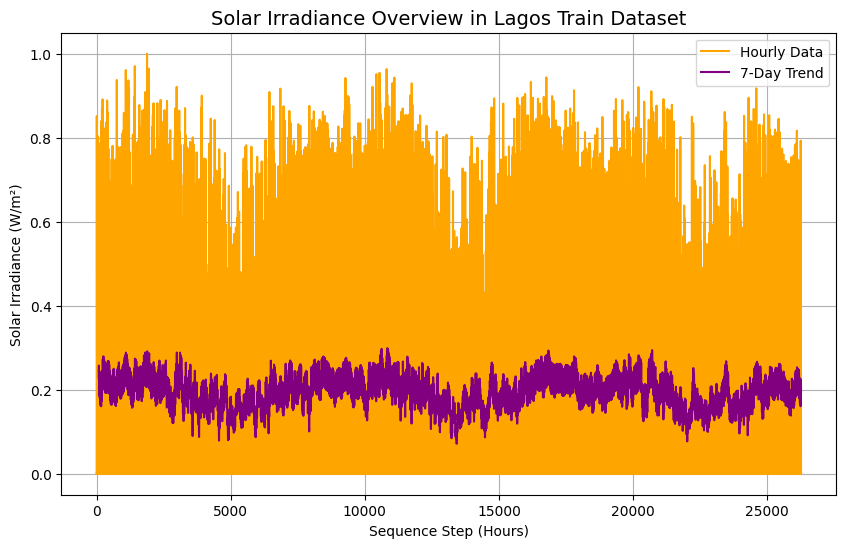

,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,CLOUD_AMT,SZA,T2M,RH2M,PS,WS2M,Hour_sine,Hour_cosine,DayOfYear_sine,DayOfYear_cosine
0,0.000000,0.000000,0.3011,1.000000,0.394065,0.301109,0.441176,0.132328,0.000000,1.000000e+00,0.017202,0.999852
1,0.000000,0.000000,0.2131,1.000000,0.293996,0.416818,0.404412,0.182580,0.258819,9.659258e-01,0.017202,0.999852
2,0.000000,0.000000,0.0799,1.000000,0.220152,0.523589,0.389706,0.242881,0.500000,8.660254e-01,0.017202,0.999852
3,0.000000,0.000000,0.0472,1.000000,0.179434,0.592783,0.397059,0.311558,0.707107,7.071068e-01,0.017202,0.999852
4,0.000000,0.000000,0.0354,1.000000,0.137336,0.655355,0.419118,0.328308,0.866025,5.000000e-01,0.017202,0.999852
5,0.000000,0.000000,0.0562,1.000000,0.095238,0.703029,0.455882,0.329983,0.965926,2.588190e-01,0.017202,0.999852
6,0.059394,0.059760,0.0466,0.920654,0.096618,0.710147,0.500000,0.341709,1.000000,6.123234e-17,0.017202,0.999852
7,0.274024,0.275391,0.0372,0.762080,0.153899,0.627545,0.551471,0.376884,0.965926,-2.588190e-01,0.017202,0.999852
8,0.497972,0.497833,0.0277,0.609901,0.244997,0.567290,0.580882,0.303183,0.866025,-5.000000e-01,0.017202,0.999852
9,0.694991,0.692684,0.0183,0.469919,0.390614,0.473432,0.558824,0.261307,0.707107,-7.071068e-01,0.017202,0.999852


In [8]:
print(f"Target column starts at index: {id}")
plt.figure(figsize=(10, 6))
plt.plot(lagos_test[target_col], color='orange', label='Hourly Data')
plt.title('Solar Irradiance Overview in Lagos Test Dataset', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.figure(figsize=(10, 6))
plt.plot(lagos_train[target_col], color='orange', label='Hourly Data')
# # Adding a rolling mean to see the seasonal trend (e.g., 7-day window)
# If your day is ~12 steps after cleaning, 7 days = 84 steps
plt.plot(lagos_train[target_col].rolling(window=84).mean(), color='purple', label='7-Day Trend')
plt.title('Solar Irradiance Overview in Lagos Train Dataset', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.show()
lagos_train.head(10)

In [9]:
# Create the Dataset objects for both cities
# This uses the data frames returned by your data_splitting function
chester_ds = SolarDataset(chester_train, window=48, forecast=24)

# Create the DataLoaders
# batch_size=32: We process 32 different 'days' at the same time to speed up math
# shuffle=True: We mix up the days so the model doesn't just memorize the calendar
# drop_last=True: If the last batch is smaller than 32, we ignore it to keep math consistent
chester_loader = DataLoader(chester_ds, batch_size=32, shuffle=True, drop_last=True)

In [10]:
train_x, train_y = next(iter(chester_loader))

# This shows the 3D shape: [Number of Windows, Number of Hours, Number of Features]
print(f"Input Shape: {train_x.shape}")

# This shows the 2D Target: [Number of Windows, Number of Hours to Predict]
print(f"Target Shape: {train_y.shape}") 


Input Shape: torch.Size([32, 48, 12])
Target Shape: torch.Size([32, 24])


In [ ]:
#Train LSTM for Chester

lstm_chester = solar_predictor_model(12, 64, model_type='LSTM')

train_my_model(lstm_chester, chester_loader, epochs=100)

Starting Training for LSTM...
Epoch [10/100],  Loss: 0.004132
Epoch [20/100],  Loss: 0.003102
Epoch [30/100],  Loss: 0.001307
Epoch [40/100],  Loss: 0.000781
Epoch [50/100],  Loss: 0.000577
Epoch [60/100],  Loss: 0.000511
Epoch [70/100],  Loss: 0.000406
Epoch [80/100],  Loss: 0.000413
Epoch [90/100],  Loss: 0.000333
Epoch [100/100],  Loss: 0.000327
Training Complete!


In [12]:

print(len(chester_test))  # Check the column length to confirm
chester_ds_test = SolarDataset(chester_test, window=48, forecast=24)
# 3. Create the loader
chester_test_loader = DataLoader(chester_ds_test, batch_size=32, shuffle=False)

# Get predictions for LSTM
chester_lstm_preds, chester_actuals = test_model(lstm_chester, chester_test_loader)



72


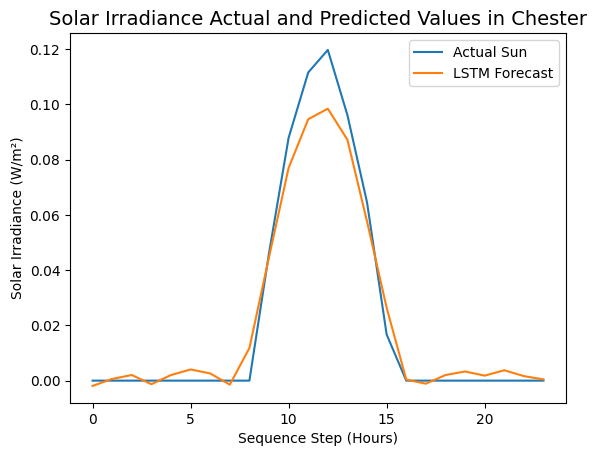

Actual values for the first test window: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.0461644  0.08792952 0.11159117
 0.11974842 0.09612052 0.06452665 0.0167083  0.         0.
 0.         0.         0.         0.         0.         0.        ]
LSTM predictions for the first test window: [-0.00191477  0.00062056  0.00203462 -0.00129467  0.00201952  0.0040452
  0.0026068  -0.00144786  0.01179921  0.04471841  0.07703106  0.09465623
  0.09847058  0.08721385  0.05761332  0.02640936  0.00037112 -0.00110422
  0.00202427  0.0033159   0.00180266  0.00376153  0.00163746  0.00045021]


In [13]:
# To see your December 30th forecast:
plt.plot(chester_actuals[0], label='Actual Sun')
plt.plot(chester_lstm_preds[0], label='LSTM Forecast')
plt.title('Solar Irradiance Actual and Predicted Values in Chester', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.show()
print("Actual values for the first test window:", chester_actuals[0])
print("LSTM predictions for the first test window:", chester_lstm_preds[0])

In [ ]:
df = pd.DataFrame({
    'Hour': list(range(0, 24)),
    'Chester Actual': chester_actuals[0],
    'lstm_chester Predictions': chester_lstm_preds[0] 
})
display(df)

,Hour,Chester Actual,lstm_chester Predictions
0,0,0.000000,-0.001915
1,1,0.000000,0.000621
2,2,0.000000,0.002035
3,3,0.000000,-0.001295
4,4,0.000000,0.002020
5,5,0.000000,0.004045
6,6,0.000000,0.002607
7,7,0.000000,-0.001448
8,8,0.000000,0.011799
9,9,0.046164,0.044718


In [15]:
#evaluate model predictions with standard error metrics R squared and mean squared error (MSE)

r2, rmse = evaluate_model(chester_actuals, chester_lstm_preds)
print(f"R-Squared Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R-Squared Score: 0.9659
RMSE: 0.0074


In [16]:
####Lagos DS

In [17]:
lagos_ds = SolarDataset(lagos_train, window=48, forecast=24)


# Create the DataLoaders
# batch_size=32: We process 32 different 'days' at the same time to speed up math
# shuffle=True: We mix up the days so the model doesn't just memorize the calendar
# drop_last=True: If the last batch is smaller than 32, we ignore it to keep math consistent
lagos_loader = DataLoader(lagos_ds, batch_size=32, shuffle=True, drop_last=True)

In [18]:
# next(iter(...)) pulls the very first 'tray' off the conveyor belt
train_x, train_y = next(iter(lagos_loader))

# This shows the 3D shape: [Number of Windows, Number of Hours, Number of Features]
print(f"Input Shape: {train_x.shape}")   

# This shows the 2D Target: [Number of Windows, Number of Hours to Predict]
print(f"Target Shape: {train_y.shape}") 

Input Shape: torch.Size([32, 48, 12])
Target Shape: torch.Size([32, 24])


In [19]:
#train lstm
lstm_lagos = solar_predictor_model(12, 64, model_type='LSTM')
train_my_model(lstm_lagos, lagos_loader, epochs=100)

Starting Training for LSTM...
Epoch [10/100],  Loss: 0.005115
Epoch [20/100],  Loss: 0.004102
Epoch [30/100],  Loss: 0.002325
Epoch [40/100],  Loss: 0.001390
Epoch [50/100],  Loss: 0.001019
Epoch [60/100],  Loss: 0.000766
Epoch [70/100],  Loss: 0.000645
Epoch [80/100],  Loss: 0.000616
Epoch [90/100],  Loss: 0.000537
Epoch [100/100],  Loss: 0.000502
Training Complete!


In [20]:
print(len(lagos_test))  # Check the column length to confirm
lagos_ds_test = SolarDataset(lagos_test, window=48, forecast=24)
# 3. Create the loader
lagos_test_loader = DataLoader(lagos_ds_test, batch_size=32, shuffle=False)

# Get predictions for LSTM
lagos_lstm_preds, lagos_actuals = test_model(lstm_lagos, lagos_test_loader)


72


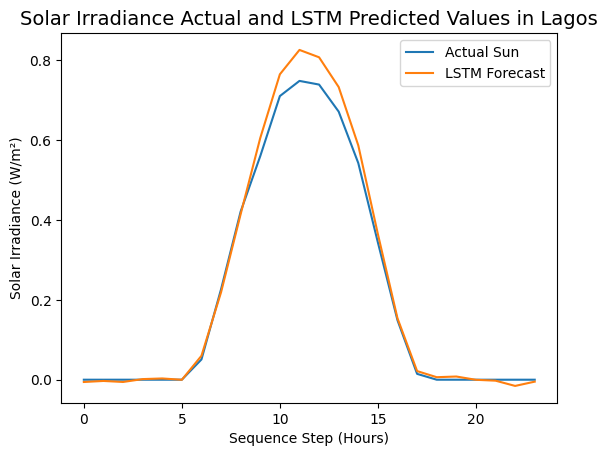

Actual values for the first test window: [0.         0.         0.         0.         0.         0.
 0.05072493 0.22660448 0.4213728  0.5601237  0.7104836  0.7484741
 0.7392984  0.67152995 0.5426037  0.3438102  0.14892021 0.01463044
 0.         0.         0.         0.         0.         0.        ]
LSTM predictions for the first test window: [-5.7085007e-03 -3.1124391e-03 -5.6422073e-03  1.5359391e-03
  3.1405985e-03 -1.5153456e-04  5.9874896e-02  2.1903089e-01
  4.1480446e-01  6.0554850e-01  7.6500672e-01  8.2607883e-01
  8.0760723e-01  7.3307717e-01  5.8684933e-01  3.6462975e-01
  1.5378416e-01  2.1573916e-02  6.2917657e-03  7.9919584e-03
 -2.2051483e-04 -2.4129674e-03 -1.5558779e-02 -4.8388466e-03]


In [21]:
# To see your December 30th forecast:
plt.plot(lagos_actuals[0], label='Actual Sun')
plt.plot(lagos_lstm_preds[0], label='LSTM Forecast')
plt.title('Solar Irradiance Actual and LSTM Predicted Values in Lagos', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.show()
print("Actual values for the first test window:", lagos_actuals[0])
print("LSTM predictions for the first test window:", lagos_lstm_preds[0])

In [22]:

df = pd.DataFrame({
    'Hour': list(range(0, 24)),
    'Lagos Actual': lagos_actuals[0],
    'LSTM Predictions': lagos_lstm_preds[0]
})
display(df)

,Hour,Lagos Actual,LSTM Predictions
0,0,0.000000,-0.005709
1,1,0.000000,-0.003112
2,2,0.000000,-0.005642
3,3,0.000000,0.001536
4,4,0.000000,0.003141
5,5,0.000000,-0.000152
6,6,0.050725,0.059875
7,7,0.226604,0.219031
8,8,0.421373,0.414804
9,9,0.560124,0.605549


In [23]:
#evaluate model predictions with standard error metrics R squared and mean squared error (MSE)
r2, rmse = evaluate_model(lagos_actuals, lagos_lstm_preds)
print(f"R-Squared Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R-Squared Score: 0.9883
RMSE: 0.0307


In [ ]:

#Train GRU for Chester
gru_chester = solar_predictor_model(12, 64, model_type='GRU')
train_my_model(gru_chester, chester_loader, epochs=100)


Starting Training for GRU...
Epoch [10/100],  Loss: 0.004174
Epoch [20/100],  Loss: 0.001922
Epoch [30/100],  Loss: 0.000986
Epoch [40/100],  Loss: 0.000734
Epoch [50/100],  Loss: 0.000621
Epoch [60/100],  Loss: 0.000537
Epoch [70/100],  Loss: 0.000487
Epoch [80/100],  Loss: 0.000451
Epoch [90/100],  Loss: 0.000424
Epoch [100/100],  Loss: 0.000404
Training Complete!


In [25]:
print(len(chester_test))  # Check the column length to confirm
chester_ds_test = SolarDataset(chester_test, window=48, forecast=24)
# 3. Create the loader
chester_test_loader = DataLoader(chester_ds_test, batch_size=32, shuffle=False)

# Get predictions for GRU
chester_gru_preds, chester_actuals = test_model(gru_chester, chester_test_loader)

72


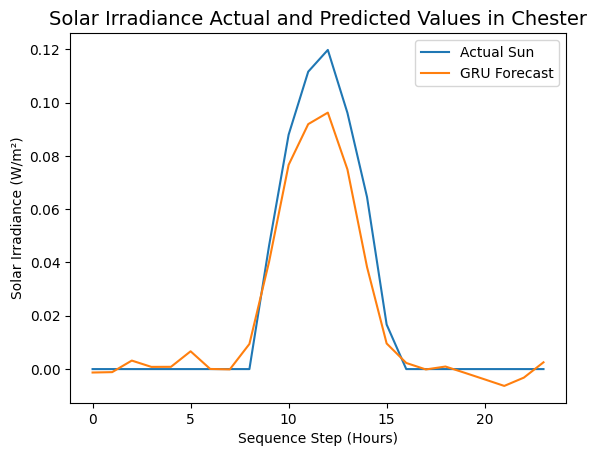

Actual values for the first test window: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.0461644  0.08792952 0.11159117
 0.11974842 0.09612052 0.06452665 0.0167083  0.         0.
 0.         0.         0.         0.         0.         0.        ]
GRU predictions for the first test window: [-1.2881760e-03 -1.1421554e-03  3.1943433e-03  8.2603609e-04
  8.5237250e-04  6.6745775e-03  4.7323294e-05 -1.1681579e-04
  9.4242245e-03  4.0159330e-02  7.6625973e-02  9.1908097e-02
  9.6223764e-02  7.4915990e-02  3.8275190e-02  9.6112657e-03
  2.2953013e-03 -1.3554259e-04  9.5813221e-04 -1.4312565e-03
 -3.8607940e-03 -6.3160714e-03 -3.2004053e-03  2.5422974e-03]


In [26]:
# To see your December 30th forecast:
plt.plot(chester_actuals[0], label='Actual Sun')
plt.plot(chester_gru_preds[0], label='GRU Forecast')
plt.title('Solar Irradiance Actual and Predicted Values in Chester', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.show()
print("Actual values for the first test window:", chester_actuals[0])
print("GRU predictions for the first test window:", chester_gru_preds[0])

In [27]:
df = pd.DataFrame({
    'Hour': list(range(0, 24)),
    'Chester Actual': chester_actuals[0],
    'GRU Predictions': chester_gru_preds[0]
})
display(df)

,Hour,Chester Actual,GRU Predictions
0,0,0.000000,-0.001288
1,1,0.000000,-0.001142
2,2,0.000000,0.003194
3,3,0.000000,0.000826
4,4,0.000000,0.000852
5,5,0.000000,0.006675
6,6,0.000000,0.000047
7,7,0.000000,-0.000117
8,8,0.000000,0.009424
9,9,0.046164,0.040159


In [28]:
#evaluate model predictions with standard error metrics R squared and mean squared error (MSE)

r2, rmse = evaluate_model(chester_actuals, chester_gru_preds)
print(f"R-Squared Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R-Squared Score: 0.9338
RMSE: 0.0103


In [29]:

# Repeat for Lagos GRU
gru_lagos = solar_predictor_model(12, 64, model_type='GRU')
train_my_model(gru_lagos, lagos_loader, epochs=100)

Starting Training for GRU...
Epoch [10/100],  Loss: 0.005177
Epoch [20/100],  Loss: 0.003354
Epoch [30/100],  Loss: 0.001605
Epoch [40/100],  Loss: 0.001096
Epoch [50/100],  Loss: 0.000885
Epoch [60/100],  Loss: 0.000753
Epoch [70/100],  Loss: 0.000679
Epoch [80/100],  Loss: 0.000631
Epoch [90/100],  Loss: 0.000598
Epoch [100/100],  Loss: 0.000555
Training Complete!


In [30]:
from test import test_model

print(len(lagos_test))  # Check the column length to confirm
lagos_ds_test = SolarDataset(lagos_test, window=48, forecast=24)
# 3. Create the loader
lagos_test_loader = DataLoader(lagos_ds_test, batch_size=32, shuffle=False)

# Get predictions for GRU
lagos_gru_preds, lagos_actuals = test_model(gru_lagos, lagos_test_loader)

72


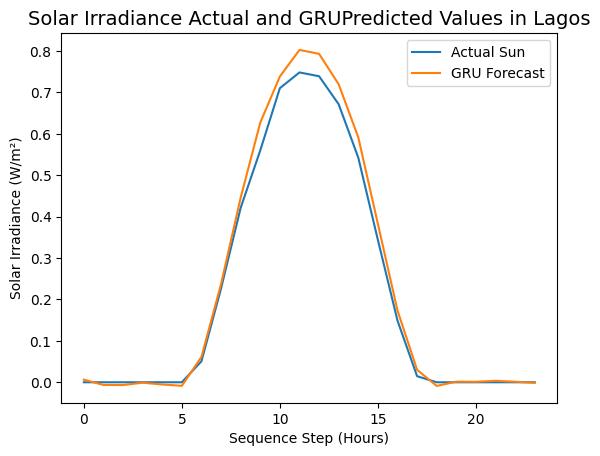

Actual values for the first test window: [0.         0.         0.         0.         0.         0.
 0.05072493 0.22660448 0.4213728  0.5601237  0.7104836  0.7484741
 0.7392984  0.67152995 0.5426037  0.3438102  0.14892021 0.01463044
 0.         0.         0.         0.         0.         0.        ]
GRU predictions for the first test window: [ 0.00628084 -0.00644263 -0.00668872 -0.00110195 -0.0053263  -0.00860736
  0.06121312  0.23736733  0.44583085  0.62727064  0.7386768   0.80285347
  0.7933768   0.7198082   0.5916781   0.38251898  0.17336957  0.02995917
 -0.00882496  0.00143215  0.00107664  0.00349267  0.00120969 -0.00140332]


In [31]:
# To see your December 30th forecast:
plt.plot(lagos_actuals[0], label='Actual Sun')
plt.plot(lagos_gru_preds[0],  label='GRU Forecast')
plt.title('Solar Irradiance Actual and GRUPredicted Values in Lagos', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.show()
print("Actual values for the first test window:", lagos_actuals[0])
print("GRU predictions for the first test window:", lagos_gru_preds[0])

In [32]:
df = pd.DataFrame({
    'Hour': list(range(0, 24)),
    'Lagos Actual': lagos_actuals[0],
    'GRU Predictions': lagos_lstm_preds[0]
})
display(df)

,Hour,Lagos Actual,GRU Predictions
0,0,0.000000,-0.005709
1,1,0.000000,-0.003112
2,2,0.000000,-0.005642
3,3,0.000000,0.001536
4,4,0.000000,0.003141
5,5,0.000000,-0.000152
6,6,0.050725,0.059875
7,7,0.226604,0.219031
8,8,0.421373,0.414804
9,9,0.560124,0.605549


In [33]:
#evaluate model predictions with standard error metrics R squared and mean squared error (MSE)

from evaluate import evaluate_model

r2, rmse = evaluate_model(lagos_actuals, lagos_gru_preds)
print(f"R-Squared Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R-Squared Score: 0.9899
RMSE: 0.0284


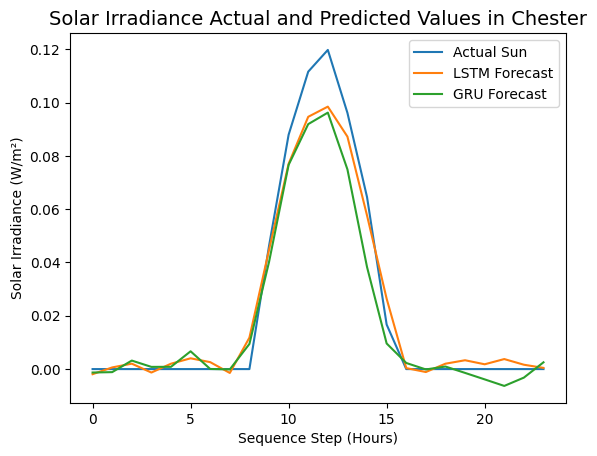

Actual values for the first test window: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.0461644  0.08792952 0.11159117
 0.11974842 0.09612052 0.06452665 0.0167083  0.         0.
 0.         0.         0.         0.         0.         0.        ]
LSTM predictions for the first test window: [-0.00191477  0.00062056  0.00203462 -0.00129467  0.00201952  0.0040452
  0.0026068  -0.00144786  0.01179921  0.04471841  0.07703106  0.09465623
  0.09847058  0.08721385  0.05761332  0.02640936  0.00037112 -0.00110422
  0.00202427  0.0033159   0.00180266  0.00376153  0.00163746  0.00045021]
GRU predictions for the first test window: [-1.2881760e-03 -1.1421554e-03  3.1943433e-03  8.2603609e-04
  8.5237250e-04  6.6745775e-03  4.7323294e-05 -1.1681579e-04
  9.4242245e-03  4.0159330e-02  7.6625973e-02  9.1908097e-02
  9.6223764e-02  7.4915990e-02  3.8275190e-02  9.6112657e-03
  2.2953013e-03 -1.3554259e-04  9.5813221e-04 -1.4312565e-03
 -3.8607940e-03 -6.316

In [34]:
# To see both LSTM and GRU forecasts for the same test window:
plt.plot(chester_actuals[0], label='Actual Sun')
plt.plot(chester_lstm_preds[0], label='LSTM Forecast')
plt.plot(chester_gru_preds[0], label='GRU Forecast')
plt.title('Solar Irradiance Actual and Predicted Values in Chester', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.show()
print("Actual values for the first test window:", chester_actuals[0])
print("LSTM predictions for the first test window:", chester_lstm_preds[0])
print("GRU predictions for the first test window:", chester_gru_preds[0])

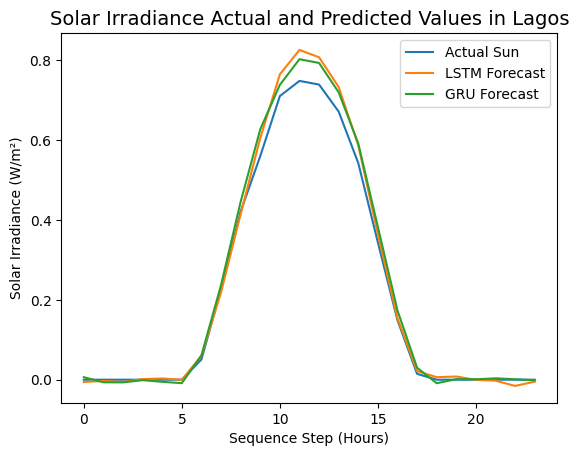

Actual values for the first test window: [0.         0.         0.         0.         0.         0.
 0.05072493 0.22660448 0.4213728  0.5601237  0.7104836  0.7484741
 0.7392984  0.67152995 0.5426037  0.3438102  0.14892021 0.01463044
 0.         0.         0.         0.         0.         0.        ]
LSTM predictions for the first test window: [-5.7085007e-03 -3.1124391e-03 -5.6422073e-03  1.5359391e-03
  3.1405985e-03 -1.5153456e-04  5.9874896e-02  2.1903089e-01
  4.1480446e-01  6.0554850e-01  7.6500672e-01  8.2607883e-01
  8.0760723e-01  7.3307717e-01  5.8684933e-01  3.6462975e-01
  1.5378416e-01  2.1573916e-02  6.2917657e-03  7.9919584e-03
 -2.2051483e-04 -2.4129674e-03 -1.5558779e-02 -4.8388466e-03]
GRU predictions for the first test window: [ 0.00628084 -0.00644263 -0.00668872 -0.00110195 -0.0053263  -0.00860736
  0.06121312  0.23736733  0.44583085  0.62727064  0.7386768   0.80285347
  0.7933768   0.7198082   0.5916781   0.38251898  0.17336957  0.02995917
 -0.00882496  0.00143215  

In [35]:
plt.plot(lagos_actuals[0], label='Actual Sun')
plt.plot(lagos_lstm_preds[0], label='LSTM Forecast')
plt.plot(lagos_gru_preds[0], label='GRU Forecast')
plt.title('Solar Irradiance Actual and Predicted Values in Lagos', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.show()
print("Actual values for the first test window:", lagos_actuals[0])
print("LSTM predictions for the first test window:", lagos_lstm_preds[0])
print("GRU predictions for the first test window:", lagos_gru_preds[0])

In [36]:
# Check the device of the first parameter in your model
print(next(lstm_chester.parameters()).device)
print(next(lstm_lagos.parameters()).device)
print(next(gru_chester.parameters()).device)
print(next(gru_lagos.parameters()).device)

cpu
cpu
cpu
cpu


In [37]:
import numpy as np

chester_gru_df = pd.DataFrame({
    'step': np.tile(np.arange(np.shape(chester_gru_preds)[1]), len(chester_gru_preds)),
    'prediction': np.asarray(chester_gru_preds).ravel()
})
chester_gru_df.to_csv('gru_chester_predictions.csv', index=False)

lagos_gru_df = pd.DataFrame({
    'step': np.tile(np.arange(np.shape(lagos_gru_preds)[1]), len(lagos_gru_preds)),
    'prediction': np.asarray(lagos_gru_preds).ravel()
})
lagos_gru_df.to_csv('gru_lagos_predictions.csv', index=False)

chester_lstm_df = pd.DataFrame({
    'step': np.tile(np.arange(np.shape(chester_lstm_preds)[1]), len(chester_lstm_preds)),
    'prediction': np.asarray(chester_lstm_preds).ravel()
})
chester_lstm_df.to_csv('lstm_chester_predictions.csv', index=False)

lagos_lstm_df = pd.DataFrame({
    'step': np.tile(np.arange(np.shape(lagos_lstm_preds)[1]), len(lagos_lstm_preds)),
    'prediction': np.asarray(lagos_lstm_preds).ravel()
})
lagos_lstm_df.to_csv('lstm_lagos_predictions.csv', index=False)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

raw_chester = pd.read_csv('./data_chester.csv')
raw_lagos = pd.read_csv('./data_lagos.csv')

# Chester (temperate) and Lagos (tropical) have very different solar
# irradiance ranges, so each location needs its own scaler.
chester_scaler = MinMaxScaler()
chester_scaler.fit_transform(raw_chester[raw_chester.columns[5]].values.reshape(-1, 1))

lagos_scaler = MinMaxScaler()
lagos_scaler.fit_transform(raw_lagos[raw_lagos.columns[5]].values.reshape(-1, 1))


# Descale predictions 
solarIrradiance_gruchester = chester_scaler.inverse_transform(chester_gru_preds)
solarIrradiance_lstmchester = chester_scaler.inverse_transform(chester_lstm_preds)
solarIrradiance_grulagos = lagos_scaler.inverse_transform(lagos_gru_preds)
solarIrradiance_lstmlagos = lagos_scaler.inverse_transform(lagos_lstm_preds)

# Descale the actuals too, so comparisons sit on the same real-world scale
chester_actuals_real = chester_scaler.inverse_transform(chester_actuals)
lagos_actuals_real = lagos_scaler.inverse_transform(lagos_actuals)

# Sanity check -- these should now look like plausible W/m^2 values
# (0 at night, peaking a few hundred at midday), not tiny 0-1 numbers.
print("Chester:")
display(pd.DataFrame({
    'Hour': range(24),
    'Actual': chester_actuals_real[0],
    'LSTM Prediction': solarIrradiance_lstmchester[0],
    'GRU Prediction': solarIrradiance_gruchester[0],
}))

print("Lagos:")
display(pd.DataFrame({
    'Hour': range(24),
    'Actual': lagos_actuals_real[0],
    'LSTM Prediction': solarIrradiance_lstmlagos[0],
    'GRU Prediction': solarIrradiance_grulagos[0],
}))

# Save descaled results to CSV for the dissertation write-up
pd.DataFrame({
    'step': np.tile(np.arange(solarIrradiance_gruchester.shape[1]), len(solarIrradiance_gruchester)),
    'actual': chester_actuals_real.ravel(),
    'gru_prediction': solarIrradiance_gruchester.ravel(),
    'lstm_prediction': solarIrradiance_lstmchester.ravel(),
}).to_csv('chester_descaled_predictions.csv', index=False)

pd.DataFrame({
    'step': np.tile(np.arange(solarIrradiance_grulagos.shape[1]), len(solarIrradiance_grulagos)),
    'actual': lagos_actuals_real.ravel(),
    'gru_prediction': solarIrradiance_grulagos.ravel(),
    'lstm_prediction': solarIrradiance_lstmlagos.ravel(),
}).to_csv('lagos_descaled_predictions.csv', index=False)



0         0
1         1
2         2
3         3
4         4
         ..
26275    19
26276    20
26277    21
26278    22
26279    23
Name: HR, Length: 26280, dtype: int64
Chester:


,Hour,Actual,LSTM Prediction,GRU Prediction
0,0,0.000000,-1.701807,-1.144905
1,1,0.000000,0.551539,-1.015125
2,2,0.000000,1.808332,2.839068
3,3,0.000000,-1.150681,0.734164
4,4,0.000000,1.794907,0.757572
5,5,0.000000,3.595290,5.932231
6,6,0.000000,2.316871,0.042060
7,7,0.000000,-1.286832,-0.103824
8,8,0.000000,10.486899,8.376062
9,9,41.029999,39.744827,35.692810


Lagos:


,Hour,Actual,LSTM Prediction,GRU Prediction
0,0,0.000000,-5.630294,6.194789
1,1,0.000000,-3.069799,-6.354370
2,2,0.000000,-5.564909,-6.597088
3,3,0.000000,1.514897,-1.086852
4,4,0.000000,3.097572,-5.253327
5,5,0.000000,-0.149459,-8.489435
6,6,50.029999,59.054611,60.374500
7,7,223.500000,216.030167,234.115402
8,8,415.600006,409.121643,439.722961
9,9,552.450012,597.252502,618.677002


In [39]:
display(pd.read_csv('chester_descaled_predictions.csv'))
display(pd.read_csv('lagos_descaled_predictions.csv'))

,step,actual,gru_prediction,lstm_prediction
0,0,0.00,-1.144905,-1.701807
1,1,0.00,-1.015125,0.551539
2,2,0.00,2.839068,1.808332
3,3,0.00,0.734164,-1.150681
4,4,0.00,0.757572,1.794907
5,5,0.00,5.932231,3.595290
6,6,0.00,0.042060,2.316871
7,7,0.00,-0.103824,-1.286832
8,8,0.00,8.376062,10.486899
9,9,41.03,35.692810,39.744827


,step,actual,gru_prediction,lstm_prediction
0,0,0.00000,6.194789,-5.630294
1,1,0.00000,-6.354370,-3.069799
2,2,0.00000,-6.597088,-5.564909
3,3,0.00000,-1.086852,1.514897
4,4,0.00000,-5.253327,3.097572
5,5,0.00000,-8.489435,-0.149459
6,6,50.03000,60.374500,59.054610
7,7,223.50000,234.115400,216.030170
8,8,415.60000,439.722960,409.121640
9,9,552.45000,618.677000,597.252500


In [ ]:
#compute solar power output estimation (POE) for both cities using the descaled predictions
#using an illustrative example, we can assume a solar panel wattage of 500W and 50 panels for the calculation. The formula for calculating the power output is as follows:
# Power Output (W) = number of panels * rated panel wattage * (solar irradiance/1000) 
df = pd.read_csv('chester_descaled_predictions.csv')

chester_df = df.copy()
chester_power_output = pd.DataFrame({ 
     'Hour step': chester_df['step'].copy(),
     'Actual Solar Power Output (W)': (chester_df['actual']/1000) * 50 * 500 ,
     'LSTM Solar Power Output (W)': (chester_df['lstm_prediction']/1000) * 50 * 500,
     'GRU Solar Power Output (W)': (chester_df['gru_prediction']/1000) * 50 * 500
})

print("Chester:")
display(chester_power_output)

df = pd.read_csv('lagos_descaled_predictions.csv')

lagos_df = df.copy()
lagos_power_output = pd.DataFrame({ 
     'Hour step': lagos_df['step'].copy(),
     'Actual Solar Power Output (W)': (lagos_df['actual']/1000) * 50 * 500 ,
     'LSTM Solar Power Output (W)': (lagos_df['lstm_prediction']/1000) * 50 * 500,
     'GRU Solar Power Output (W)': (lagos_df['gru_prediction']/1000) * 50 * 500
})


print("Lagos:")
display(lagos_power_output)




Chester:


,Hour step,Actual Solar Power Output (W),LSTM Solar Power Output (W),GRU Solar Power Output (W)
0,0,0.00,-42.545167,-28.622627
1,1,0.00,13.788476,-25.378122
2,2,0.00,45.208310,70.976710
3,3,0.00,-28.767017,18.354109
4,4,0.00,44.872680,18.939291
5,5,0.00,89.882250,148.305775
6,6,0.00,57.921767,1.051500
7,7,0.00,-32.170790,-2.595588
8,8,0.00,262.172475,209.401550
9,9,1025.75,993.620675,892.320250


Lagos:


,Hour step,Actual Solar Power Output (W),LSTM Solar Power Output (W),GRU Solar Power Output (W)
0,0,0.00000,-140.757357,154.869735
1,1,0.00000,-76.744968,-158.859250
2,2,0.00000,-139.122725,-164.927200
3,3,0.00000,37.872415,-27.171290
4,4,0.00000,77.439307,-131.333175
5,5,0.00000,-3.736463,-212.235875
6,6,1250.75000,1476.365250,1509.362500
7,7,5587.50000,5400.754250,5852.885000
8,8,10390.00000,10228.041000,10993.074000
9,9,13811.25000,14931.312500,15466.925000
